In [117]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")

In [3]:
train.shape

(165034, 14)

In [4]:
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 17.6 MB


In [6]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [7]:
train.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
colums = ['CreditScore','Age',
       'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember',
       'EstimatedSalary', 'Exited']


In [9]:
train['Balance'] = np.where(train['Balance'] > 0, np.log2(train['Balance']), train['Balance'])

d:\ml\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,7.699773,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,8.399514,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,16.871948,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,17.936742,4.000000,1.000000,1.000000,199992.480000,1.000000


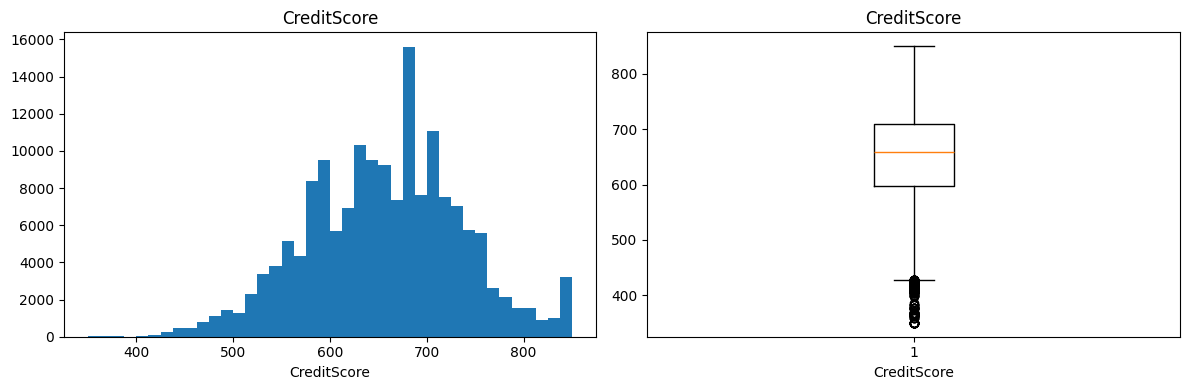

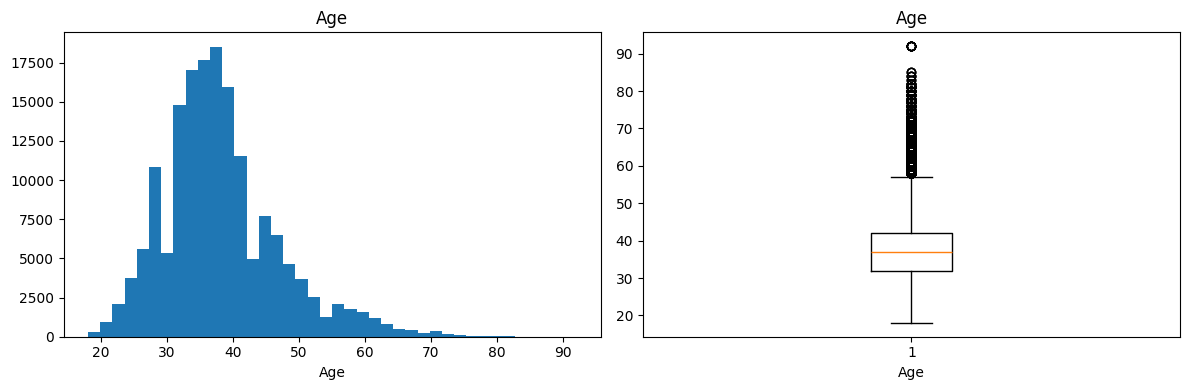

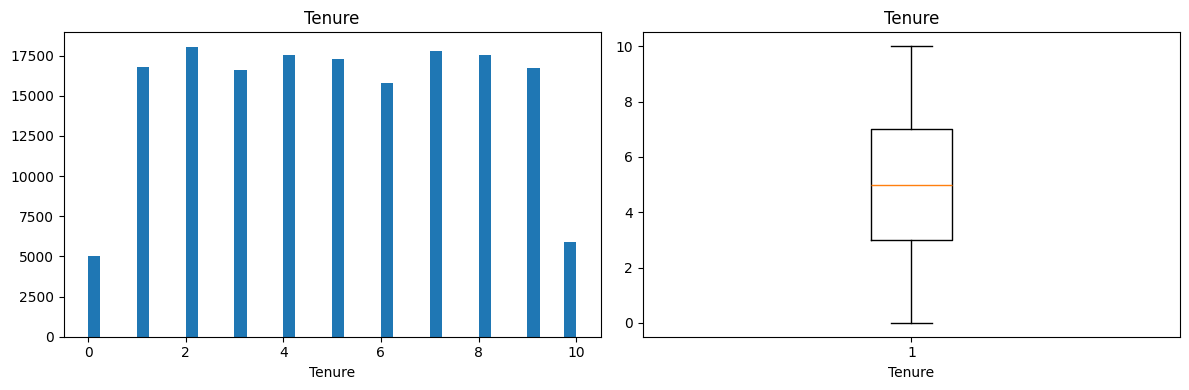

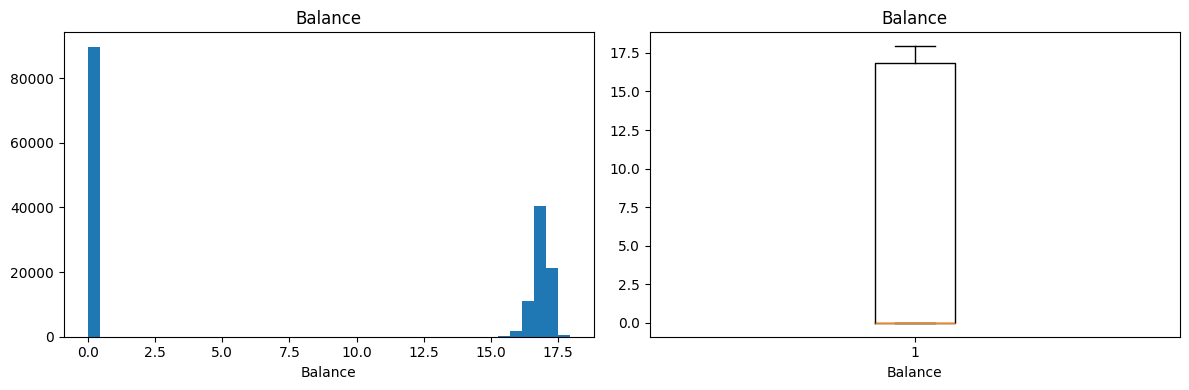

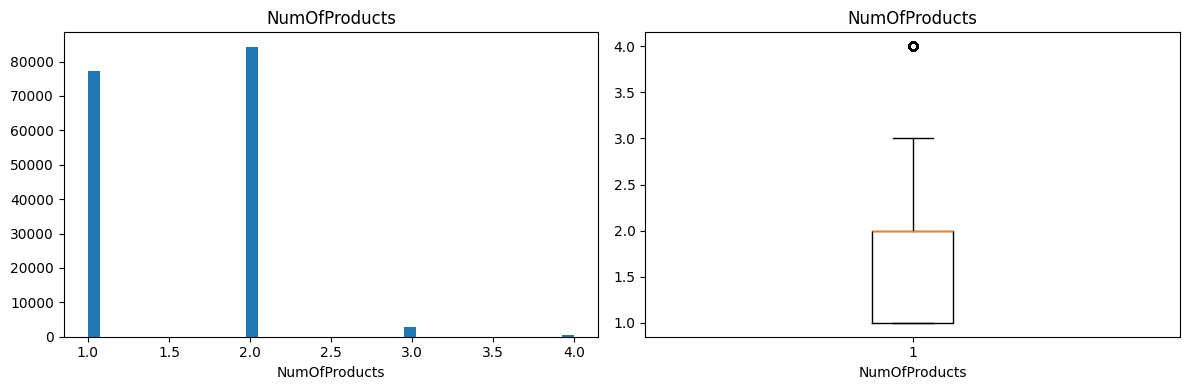

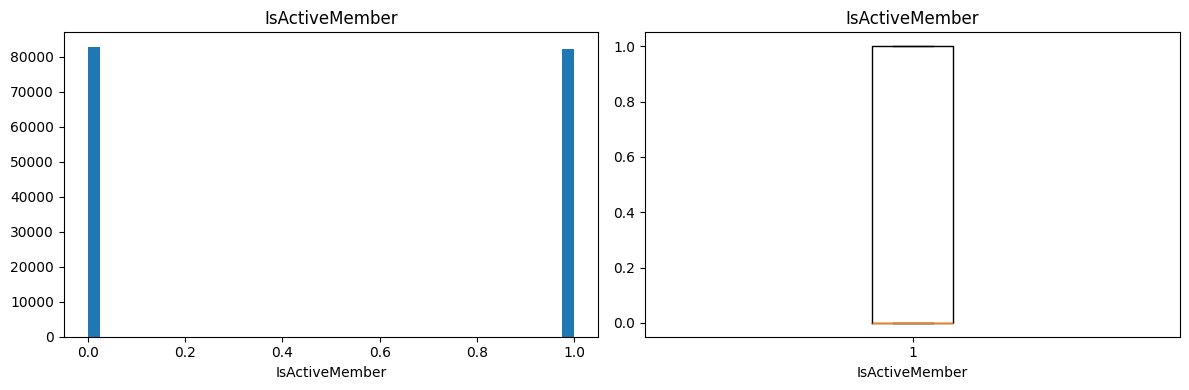

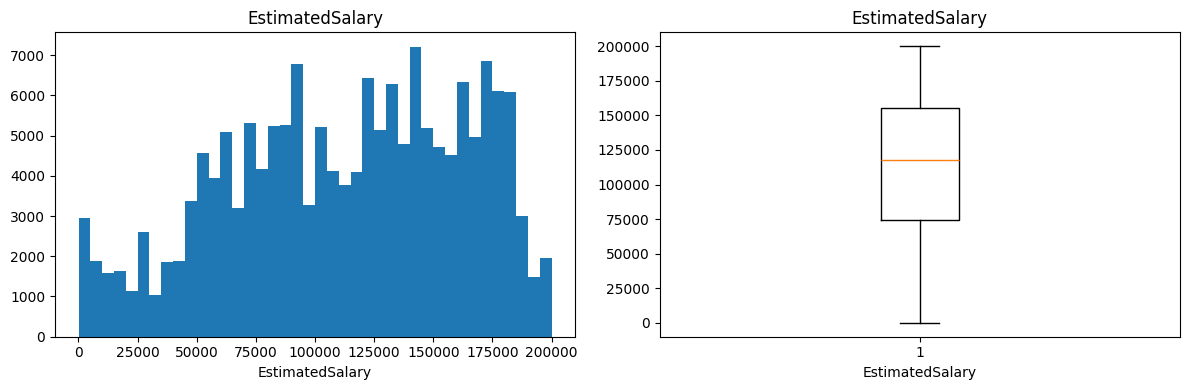

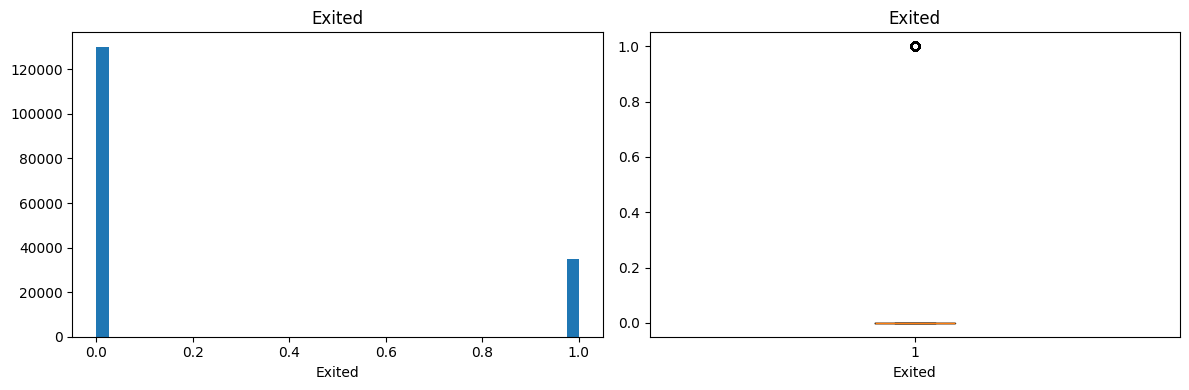

In [20]:

for col in colums:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(train[col],bins=40)
    plt.xlabel(col)
    plt.title(col)

    plt.subplot(1,2,2)
    plt.boxplot(train[col])
    plt.xlabel(col)
    plt.title(col)

    plt.tight_layout()
    plt.show()

In [16]:
train.info()
train['Gender'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   CreditScore      165034 non-null  int64  
 3   Geography        165034 non-null  str    
 4   Gender           165034 non-null  str    
 5   Age              165034 non-null  float64
 6   Tenure           165034 non-null  int64  
 7   Balance          165034 non-null  float64
 8   NumOfProducts    165034 non-null  int64  
 9   HasCrCard        165034 non-null  float64
 10  IsActiveMember   165034 non-null  float64
 11  EstimatedSalary  165034 non-null  float64
 12  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(2)
memory usage: 16.4 MB


<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [13]:
train_Geography = pd.get_dummies(train['Geography']).astype(int)

In [22]:
# train = train.drop('Surname',axis=1)
train['Gender'] = train['Gender'].replace(to_replace=['Male', 'Female'],value=[0,1]).astype(int)
train.dtypes

id                   int64
CustomerId           int64
CreditScore          int64
Geography              str
Gender               int64
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object

In [31]:
train_Geography = pd.get_dummies(train['Geography']).astype(int)
train = train.drop('Geography',axis=1)
train_Geography.head()

,France,Germany,Spain
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,0,1


In [32]:
train_x_y= pd.concat([train,train_Geography],axis=1)
train_x_y.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   CreditScore      165034 non-null  int64  
 3   Gender           165034 non-null  int64  
 4   Age              165034 non-null  float64
 5   Tenure           165034 non-null  int64  
 6   Balance          165034 non-null  float64
 7   NumOfProducts    165034 non-null  int64  
 8   HasCrCard        165034 non-null  float64
 9   IsActiveMember   165034 non-null  float64
 10  EstimatedSalary  165034 non-null  float64
 11  Exited           165034 non-null  int64  
 12  France           165034 non-null  int64  
 13  Germany          165034 non-null  int64  
 14  Spain            165034 non-null  int64  
dtypes: float64(5), int64(10)
memory usage: 18.9 MB


In [34]:
x = train_x_y.drop('Exited',axis=1)
y = train_x_y['Exited']

In [50]:
x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.2,random_state=42, stratify=y)

x_val.shape


(132028, 14)

In [118]:
model = GradientBoostingClassifier(
    loss='exponential',
    learning_rate=0.03,
    n_estimators=300,
    max_depth=5,
    subsample=0.7,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    verbose=1,
    tol=1e-4,
    n_iter_no_change=10,
)

In [119]:
model.fit(x_train,y_train)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.8089           0.0101           14.63s
         2           0.7944          -0.0009           16.41s
         3           0.7851           0.0104           16.62s
         4           0.7789           0.0158           16.05s
         5           0.7670           0.0023           16.06s
         6           0.7558           0.0020           15.82s
         7           0.7520           0.0179           15.62s
         8           0.7410           0.0007           15.39s
         9           0.7355           0.0124           15.21s
        10           0.7308           0.0127           15.25s
        20           0.6717          -0.0016           14.66s
        30           0.6349           0.0104           14.11s
        40           0.6136           0.0137           13.53s
        50           0.5912          -0.0024           12.94s
        60           0.5776          -0.0123           12.41s
       

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'exponential'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.03
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N

In [109]:
y_pred = model.predict(x_val)

In [110]:
accuracy = accuracy_score(y_val,y_pred)
accuracy


0.8642712151967764

In [111]:
a = classification_report(y_val,y_pred,target_names=['Остался', 'Ушел'])
print(a)

              precision    recall  f1-score   support

     Остался       0.88      0.95      0.92    104091
        Ушел       0.76      0.53      0.62     27937

    accuracy                           0.86    132028
   macro avg       0.82      0.74      0.77    132028
weighted avg       0.86      0.86      0.85    132028



In [105]:
w = model.feature_importances_

[print(i) for i in w]


0.027243072586289198
0.02890283726407199
0.024870718332301818
0.028611437482577023
0.3519551700715678
0.0108980354095686
0.06636644591451507
0.2808882771395944
0.00367580877425319
0.09911570694508957
0.036245499081862885
0.001380005568183809
0.03888961295396959
0.0009573724761550064


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [106]:
[print(i) for i in x.columns]

id
CustomerId
CreditScore
Gender
Age
Tenure
Balance
NumOfProducts
HasCrCard
IsActiveMember
EstimatedSalary
France
Germany
Spain


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]